# Project #3: NHTS and NGSIM Data Visualization  
**Client:** Federal Highway Adminsitration (FHWA)


In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style('whitegrid')
sns.set_palette('deep')

In [3]:
#Load in NHTS dataset
nhts_data = pd.read_csv('NHTS.csv')
nhts_data.head(1)

,household_id,census_division,census_region,driver_count,household_income,household_size,household_workers,home_type,household_location,number_adults_household,...,urban,vehicle_type,hybrid,make,vehicle_age,vehicle_commercial,vehicle_delivery,vehicle_rideshare,fuel_type,vehicle_year
0,9000013002,New England,Northeast,2,"$175,000 or more",4,1,One-family detached,Urban,2,...,In an urban area,"SUV (Santa Fe, Tahoe, Jeep, etc.)",No,Subaru,7,No,NaN,NaN,Gas,2015


In [11]:
# Load in NGSIM dataset
ngsim_data = pd.read_csv('NGSIM.csv')
ngsim_data.head(1)

,Time,leader_position(m),follower_position(m),leader_speed(m/s),follower_speed(m/s),leader_acc(m/s^2),follower_acc(m/s^2),trajectory_number
0,0.1,26.654,0.0,14.054,14.484,1.0973,-0.03048,1


## Part 1: Data Visualization

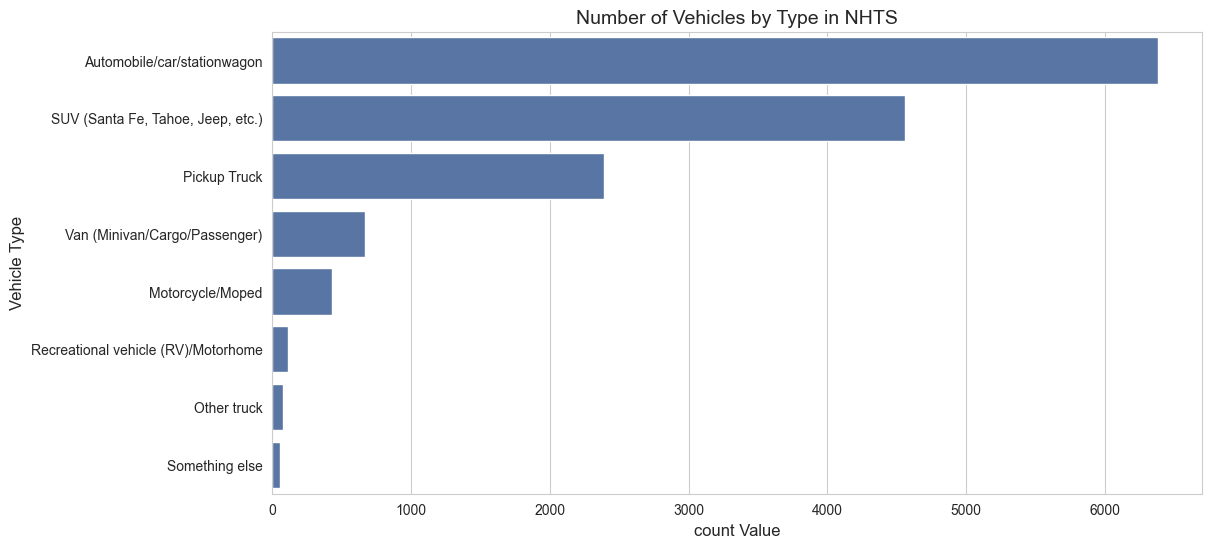

In [5]:
# Plot 1: Bar Graph

# Set plot size
plt.figure(figsize = (12,6))

# Create plot
sns.countplot(data=nhts_data, y='vehicle_type', order=nhts_data['vehicle_type'].value_counts().index)

## Labels and title
plt.xlabel('count Value', fontsize = 12)
plt.ylabel('Vehicle Type', fontsize = 12)
plt.title('Number of Vehicles by Type in NHTS', fontsize = 14)

plt.show()

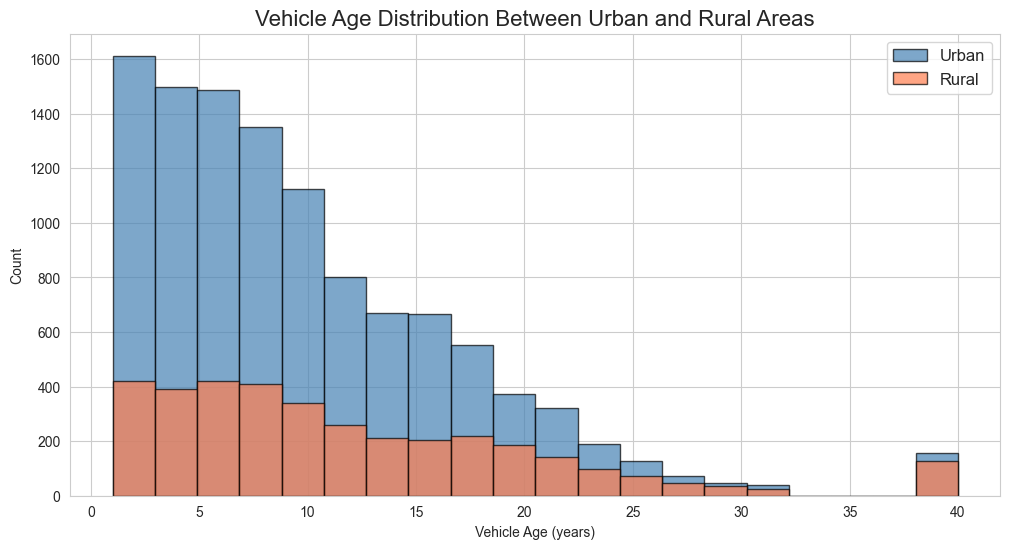

In [8]:
# Plot 2: Histogram

# Set plot size
plt.figure(figsize=(12,6))

# Filter and plot Urban and Rural vehicle ages
urban_ages = nhts_data[nhts_data['household_location'] == 'Urban']['vehicle_age']
plt.hist(urban_ages, bins = 20, edgecolor = 'black', alpha = 0.7, color = 'steelblue', label = 'Urban')

rural_ages = nhts_data[nhts_data['household_location'] == 'Rural']['vehicle_age']
plt.hist(rural_ages, bins = 20, edgecolor = 'black', alpha = 0.7, color = 'coral', label = 'Rural')

# Labels, title, and legend
plt.title('Vehicle Age Distribution Between Urban and Rural Areas', fontsize = 16)
plt.xlabel('Vehicle Age (years)')
plt.ylabel('Count')
plt.legend(fontsize = 12)
plt.show()

<Figure size 1400x600 with 0 Axes>

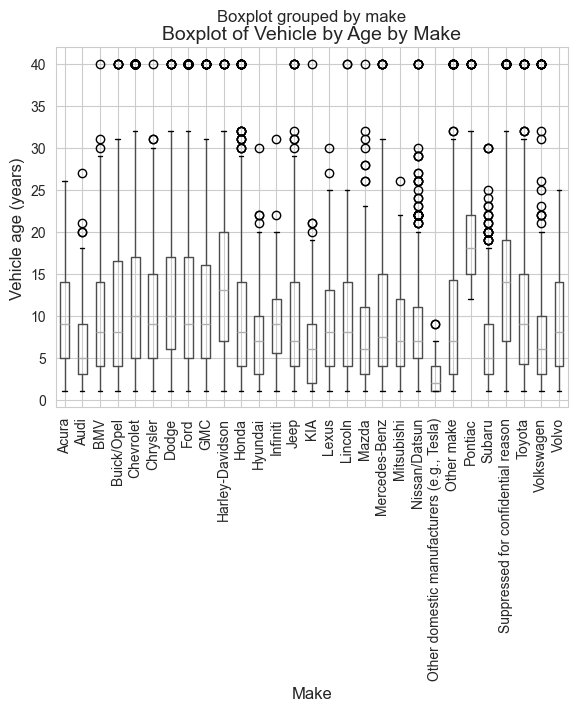

In [12]:
# Plot 3: Box Plot

# Set plot size
plt.figure(figsize=(14,6))

# Create plot
boxplot=nhts_data.boxplot(column='vehicle_age', by='make')

# Rotate Labels
plt.xticks(rotation=90)

# Labels, title, and legend
plt.xlabel('Make', fontsize=12)
plt.ylabel('Vehicle age (years)', fontsize=12)
plt.title('Boxplot of Vehicle by Age by Make', fontsize=14)
plt.show()

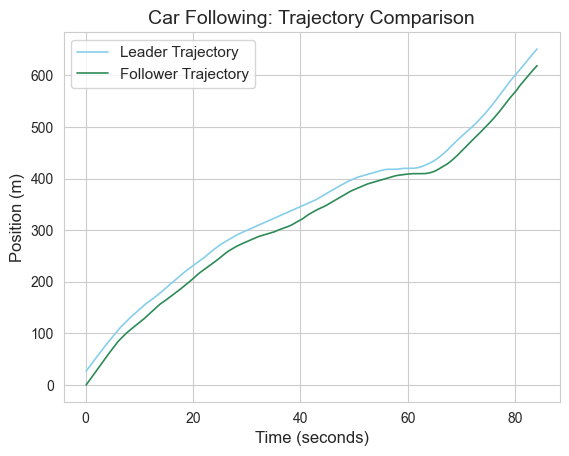

In [17]:
# Plot 4: Time-series 1

# Select a trajectory number
trajectory_number = 1 # vehicle pair x

# select the data based on the subset 
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]

# Plot the position of both vehicles over time
sns.lineplot(x=data_subset['Time'], y=data_subset['leader_position(m)'], color = 'skyblue', linewidth=1.2, label='Leader Trajectory')
sns.lineplot(x=data_subset['Time'], y=data_subset['follower_position(m)'], color = 'seagreen', linewidth=1.2, label='Follower Trajectory')

# Labels, title, and legend
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Position (m)', fontsize=12)
plt.title('Car Following: Trajectory Comparison', fontsize=14)
plt.legend(fontsize=11)
plt.show()

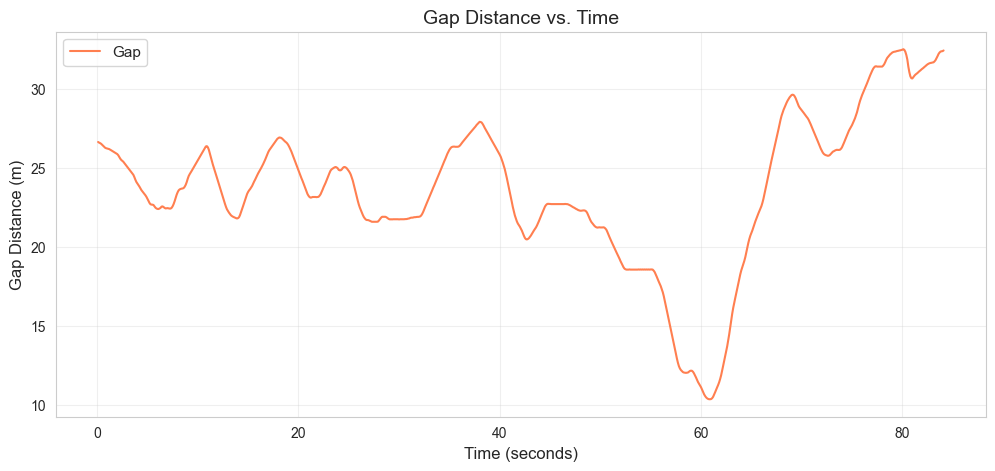

In [18]:
# Plot 5: Time-series 2

# Set plot size
plt.figure(figsize=(12,5))

# Plot the gap distance over time 
gap_distance = (data_subset['leader_position(m)'] - data_subset['follower_position(m)'])
sns.lineplot(x=data_subset['Time'], y=gap_distance, label='Gap', color = 'coral', linewidth = 1.5)

# Labels, title, and legend
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Gap Distance (m)', fontsize=12)
plt.title('Gap Distance vs. Time', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

## Part 2: IDM Simulation

#### IDM Function Definition

In [19]:
# Define the IDM acceleration function
# The function should take the following inputs:
#   v      : current speed of the follower vehicle (m/s)
#   s      : current gap distance between leader and follower (m)
#   delta_v : speed difference = follower speed - leader speed (m/s)
#   v0     : desired velocity (m/s)
#   s0     : minimum spacing (m)
#   T      : desired time headway (s)
#   a      : maximum acceleration (m/s^2)
#   b      : comfortable deceleration (m/s^2)
#   delta  : acceleration exponent

def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    # Calculate the desired minimum gap s_star
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))
    
    # Make sure s_star is not negative
    s_star = max(s_star, s0)
    
    # Calculate the acceleration using the IDM equation
    acceleration = a * (1 - (v/v0) ** delta - (s_star/s) ** 2)
    
    return acceleration

#### Simulation Setup

In [20]:
# Load the NGSIM data to get the leader vehicle trajectory
ngsim_data = pd.read_csv('NGSIM.csv')

# Select a trajectory pair
trajectory_number = 1
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].reset_index(drop=True)

# Extract the leader's position and speed over time
time_data = data_subset['Time'].values
leader_position = data_subset['leader_position(m)'].values
leader_speed = data_subset['leader_speed(m/s)'].values
follower_position = data_subset['follower_position(m)'].values

# Identifying the time step in our data
dt = 0.1 # every 0.1 seconds calculate new acceleration

#### Running the Simulation

In [21]:
# Set the IDM parameters
v0 = 30    # desired velocity (m/s)
s0 = 2     # minimum spacing (m)
T = 1.5    # desired time headway (s)
a_param = 1.0    # maximum acceleration (m/s^2)  
b = 1.5    # comfortable deceleration (m/s^2)
delta = 4  # acceleration exponent

# Initialize arrays to store simulation results
n_steps = time_data.size
sim_position = np.zeros(n_steps)
sim_speed = np.zeros(n_steps)
sim_acceleration = np.zeros(n_steps)

# Start at the real follower's initial state
sim_position[0] = data_subset['follower_position(m)'].values[0]
sim_speed[0] = data_subset['follower_speed(m/s)'].values[0]

In [22]:
# Run the IDM simulation
for i in range(n_steps - 1): # we do -1 since the first element is known (remember the step above) 

    # Step 1 & 2: Calculate the gap and speed difference at this time step
    gap = max(leader_position[i] - sim_position[i], 0.1) # condition prevents gap being negative
    delta_v = sim_speed[i] - leader_speed[i]

    # Step 3: Use the IDM function to calculate acceleration
    sim_acceleration[i] = idm_acceleration(sim_speed[i], gap, delta_v, v0, s0, T, a_param, b, delta)

    # Step 4 & 5: Update speed and position for the next time step
    sim_speed[i+1] = max(sim_speed[i]+sim_acceleration[i]*dt,0)
    sim_position[i+1] = sim_position[i]+sim_speed[i]*dt

print("Simulation complete!")

Simulation complete!


### Simulation Results Visualization

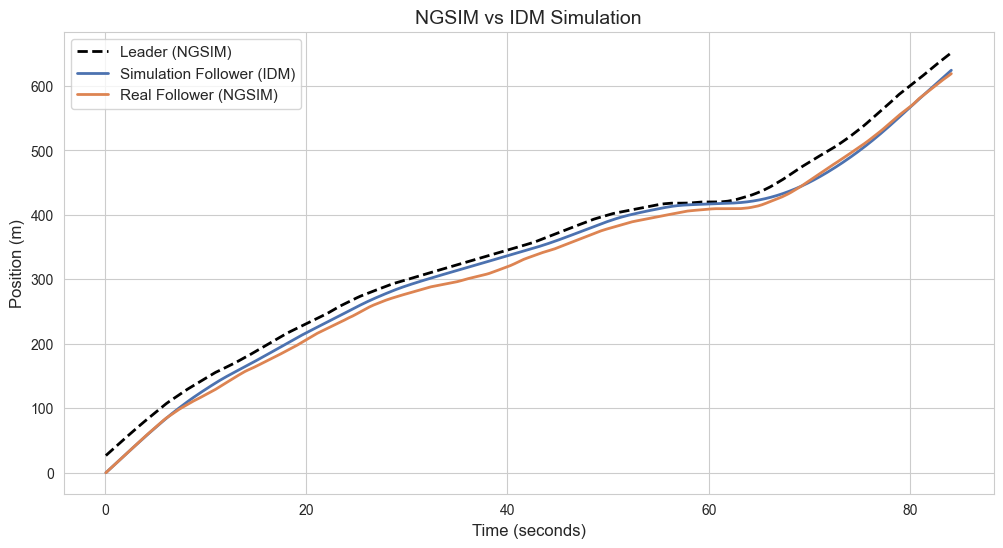

In [24]:
# Set plot size
plt.figure(figsize = (12,6))

# Plot Leader, simulation follower, and real follower
plt.plot(time_data, leader_position, 'k--', linewidth=2, label='Leader (NGSIM)')
plt.plot(time_data, sim_position, linewidth=2, label='Simulation Follower (IDM)')
plt.plot(time_data, follower_position, linewidth=2, label='Real Follower (NGSIM)')

# Labels, title, and legend
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Position (m)', fontsize=12)
plt.title('NGSIM vs IDM Simulation', fontsize=14)
plt.legend(fontsize=11)
plt.show()